### 프로젝트 개요
- 이번 프로젝트는 Claude Opus 4.6의 가상 프로젝트 생성 기능을 test하기 위해 진행하였음.
- 논리구조, 내부 코드 등을 직접 작성하는 방식이 아닌, AI가 제공한 코드들의 흐름을 따라가며 실무에서 통계적 지식들이 어떻게 사용되는지 체감하는 데 집중함.
- 최초 AI가 제시한 프로젝트의 결과 해석 방향과 새로 생성한 가상 데이터가 상이하여 결론 도출, 결과 해석 과정을 직접 수행해보았음.

In [ ]:
# 필수 라이브러리 Import
import warnings
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

시나리오: FinStar 자산운용은 AI 기반 로보어드바이저 펀드 'AlphaBot'을 출시했다. 경영진은 기존 액티브 펀드 'ClassicGrowth' 대비 수익률이 유의미하게 높은지 데이터로 검증하고자 한다. 분석팀은 최근 120개월(10년) 간 두 펀드의 월별 수익률 데이터를 확보했다.

가상 데이터 생성
1. 날짜 생성
2. 시장 국면 할당(하락장, 보합, 상승장)
3. 국면 별 수익률 파라미터
4. 수익률 생성
5. 전체 통계 확인
6. csv 파일 생성

데이터 개요

| 변수 | 유형 | 측정 척도 | 설명 |
| --- | --- | --- | --- |
| date | 시간 | 등간 | 월말 기준일 (2016-01 ~ 2025-12) |
| fund | 범주형(명목) | 명목 | 'AlphaBot' / 'ClassicGrowth' |
| monthly_return | 수치형(연속) | 비율 | 월별 수익률 (%) |
| market_regime | 범주형(순서) | 순서 | 시장 국면: Bear / Neutral / Bull |

In [4]:
import numpy as np
import pandas as pd

np.random.seed(42)

# ── 1. 날짜 생성 (120개월: 2016-01 ~ 2025-12) ──
dates = pd.date_range('2016-01-31', periods=120, freq='ME')

# ── 2. 시장 국면 할당 ──
# Bear(하락장) / Neutral(보합) / Bull(상승장) 블록을 현실적으로 배치
regime_sequence = (
    ['Bull'] * 24 +      # 2016-01 ~ 2017-12
    ['Bear'] * 12 +      # 2018-01 ~ 2018-12
    ['Neutral'] * 6 +    # 2019-01 ~ 2019-06
    ['Bull'] * 18 +      # 2019-07 ~ 2020-12
    ['Bear'] * 10 +      # 2021-01 ~ 2021-10
    ['Neutral'] * 14 +   # 2021-11 ~ 2022-12
    ['Bull'] * 12 +      # 2023-01 ~ 2023-12
    ['Bear'] * 6 +       # 2024-01 ~ 2024-06
    ['Neutral'] * 6 +    # 2024-07 ~ 2024-12
    ['Bull'] * 12         # 2025-01 ~ 2025-12
)

# ── 3. 국면별 수익률 파라미터 ──
# AlphaBot: 전체 mean≈1.12, std≈3.42
# ClassicGrowth: 전체 mean≈0.78, std≈4.15
params = {
    'AlphaBot': {
        'Bear':    {'mean': -1.80, 'std': 2.80},
        'Neutral': {'mean':  0.90, 'std': 2.50},
        'Bull':    {'mean':  2.50, 'std': 3.00},
    },
    'ClassicGrowth': {
        'Bear':    {'mean': -2.50, 'std': 3.80},
        'Neutral': {'mean':  0.60, 'std': 3.20},
        'Bull':    {'mean':  2.40, 'std': 3.60},
    },
}

# ── 4. 수익률 생성 ──
rows = []
for i, (date, regime) in enumerate(zip(dates, regime_sequence)):
    for fund in ['AlphaBot', 'ClassicGrowth']:
        p = params[fund][regime]
        ret = np.random.normal(p['mean'], p['std'])
        rows.append({
            'date': date.strftime('%Y-%m'),
            'fund': fund,
            'monthly_return': round(ret, 2),
            'market_regime': regime,
        })

df = pd.DataFrame(rows)

# ── 5. 전체 통계 확인 ──
print("=== 펀드별 기술통계 ===")
check = df.groupby('fund')['monthly_return'].agg(
    count='count', mean='mean', median='median',
    std='std', skew='skew',
    kurt=lambda x: x.kurtosis()
).round(4)
print(check)

# ── 6. CSV 저장 ──
df.to_csv('fund_returns.csv', index=False)
print(f"\n✅ fund_returns.csv 저장 완료 ({len(df)}행)")

=== 펀드별 기술통계 ===
               count    mean  median     std    skew    kurt
fund                                                        
AlphaBot         120  0.9027   1.090  2.9738  0.1374  0.4327
ClassicGrowth    120  1.1117   1.555  4.1174 -0.0183  0.3603

✅ fund_returns.csv 저장 완료 (240행)


- 기술통계 확인

In [5]:
import pandas as pd
from scipy import stats

# 데이터 로드 (가상)
df = pd.read_csv('fund_returns.csv')

# 펀드별 기술통계
summary = df.groupby('fund')['monthly_return'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    skew='skew',
    kurt=lambda x: x.kurtosis()
).round(4)

# IQR 추가
for fund in ['AlphaBot', 'ClassicGrowth']:
    sub = df[df['fund'] == fund]['monthly_return']
    q1, q3 = sub.quantile(0.25), sub.quantile(0.75)
    summary.loc[fund, 'IQR'] = round(q3 - q1, 4)

display(summary)

,count,mean,median,std,skew,kurt,IQR
fund,,,,,,,
AlphaBot,120,0.9027,1.090,2.9738,0.1374,0.4327,3.4125
ClassicGrowth,120,1.1117,1.555,4.1174,-0.0183,0.3603,5.2200


### 산점도 해석
1. 두 펀드 수익률의 상관관계가 낮다.
2. 수익률 우위가 불분명하다. 기울기 1의 점선 위의 점이 많다면 Alphabot의 우위, 아래에 점이 많다면 ClassicGrowth의 우위겠지만, 양쪽 모두에 대해서 그러한 경향은 보이지 않는다.
3. AI의 보충: ClassicGrowth의 분포 범위(-10%~+13%)가 Alphabot(-6%~+10%)의 분포 범위보다 훨씬 넓다. 이는 기술통계에서 보았듯, ClassicGrowth의 표준편차가 더 크기 때문에, 변동성이 높은 것으로 확인됨.

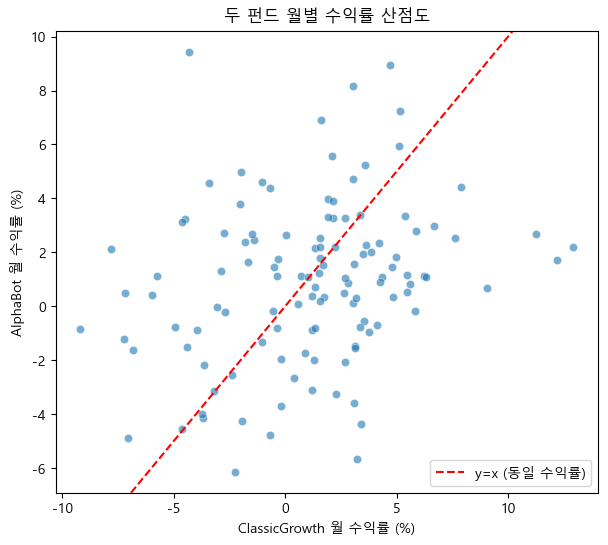

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

pivot = df.pivot(index='date', columns='fund', values='monthly_return')
plt.figure(figsize=(7, 6))
sns.scatterplot(data=pivot, x='ClassicGrowth', y='AlphaBot', alpha=0.6)
plt.axline((0, 0), slope=1, color='red', linestyle='--', label='y=x (동일 수익률)')
plt.xlabel('ClassicGrowth 월 수익률 (%)')
plt.ylabel('AlphaBot 월 수익률 (%)')
plt.title('두 펀드 월별 수익률 산점도')
plt.legend()
plt.show()

### 박스플롯 해석
1. ClassicGrowth의 상자가 더 크고, 수염이 더 긴 것을 확인할 수 있음.
2. 상위 이상치 값이 훨씬 높게 존재하는 것으로 보아, 상승 시에는 높은 퍼포먼스를 보일 가능성이 있다고 볼 수 있음.

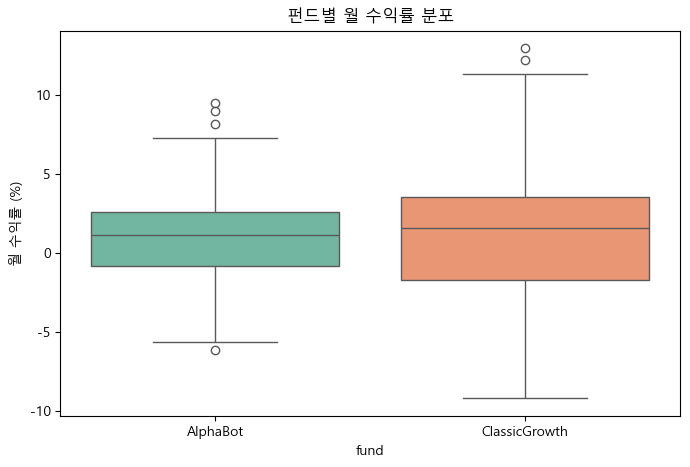

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='fund', y='monthly_return', palette='Set2')
plt.title('펀드별 월 수익률 분포')
plt.ylabel('월 수익률 (%)')
plt.show()

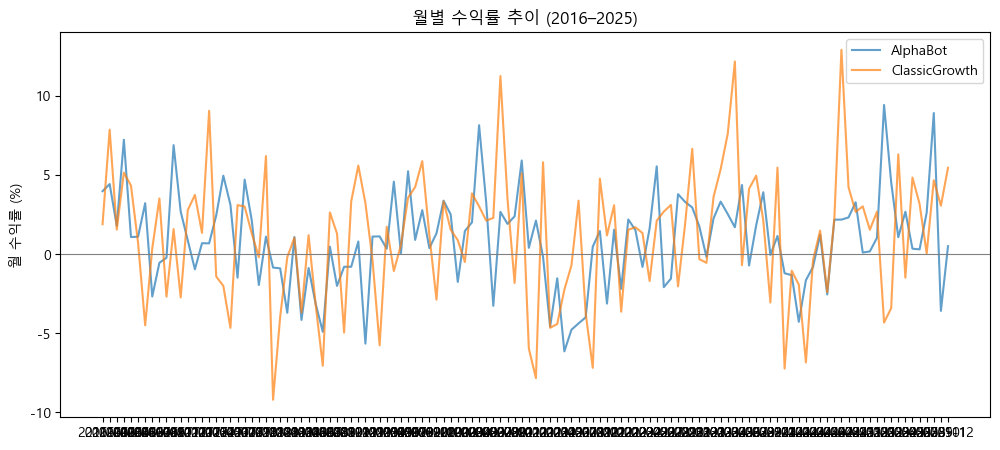

In [8]:
plt.figure(figsize=(12, 5))
for fund in ['AlphaBot', 'ClassicGrowth']:
    sub = df[df['fund'] == fund]
    plt.plot(sub['date'], sub['monthly_return'], label=fund, alpha=0.7)
plt.axhline(0, color='gray', linewidth=0.8)
plt.title('월별 수익률 추이 (2016–2025)')
plt.ylabel('월 수익률 (%)')
plt.legend()
plt.show()

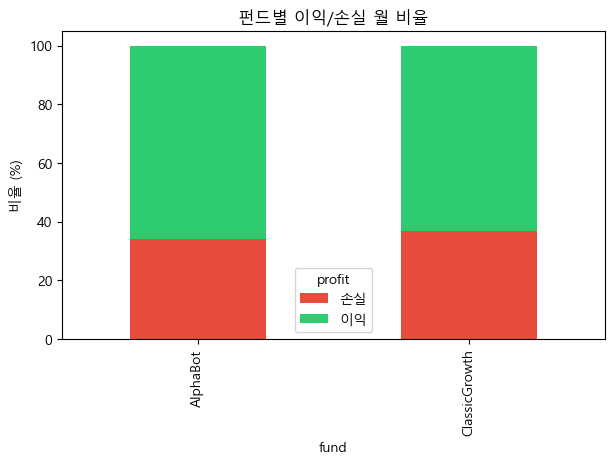

In [9]:
df['profit'] = df['monthly_return'].apply(lambda x: '이익' if x > 0 else '손실')
ct = pd.crosstab(df['fund'], df['profit'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, color=['#e74c3c','#2ecc71'], figsize=(7, 4))
plt.title('펀드별 이익/손실 월 비율')
plt.ylabel('비율 (%)')
plt.show()

In [10]:
from scipy import stats

for fund in ['AlphaBot', 'ClassicGrowth']:
    sub = df[df['fund'] == fund]['monthly_return']
    stat_w, p_w = stats.shapiro(sub)
    result = "만족" if p_w > 0.05 else "불만족"
    print(f"{fund}: W={stat_w:.3f}, p={p_w:.3f} → 정규성 {result}")

AlphaBot: W=0.987, p=0.284 → 정규성 만족
ClassicGrowth: W=0.984, p=0.152 → 정규성 만족


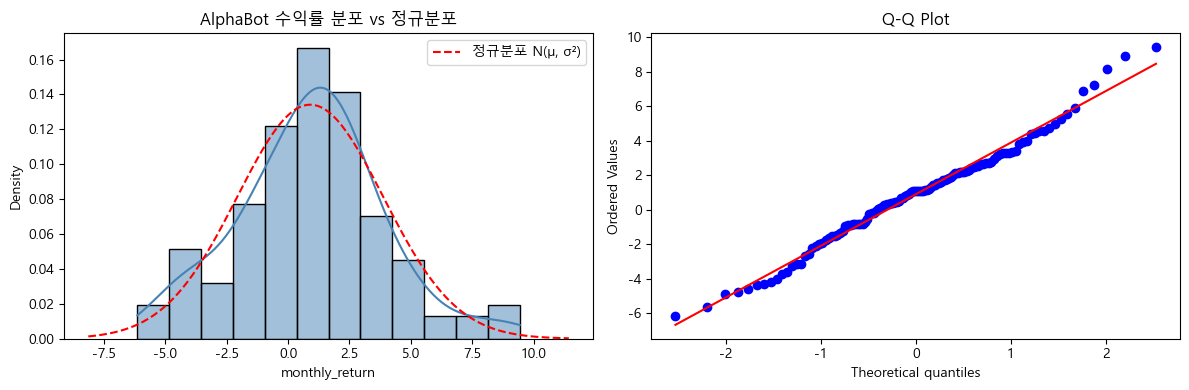

In [11]:
# AlphaBot 수익률의 정규성 시각 확인 (히스토그램 + KDE + 정규곡선)
alpha = df[df['fund'] == 'AlphaBot']['monthly_return']

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# 히스토그램 + KDE + 이론 정규분포
sns.histplot(alpha, kde=True, stat='density', ax=ax[0], color='steelblue')
import numpy as np
x = np.linspace(alpha.min()-2, alpha.max()+2, 200)
ax[0].plot(x, stats.norm.pdf(x, alpha.mean(), alpha.std()), 'r--', label='정규분포 N(μ, σ²)')
ax[0].set_title('AlphaBot 수익률 분포 vs 정규분포')
ax[0].legend()

# Q-Q Plot
stats.probplot(alpha, dist='norm', plot=ax[1])
ax[1].set_title('Q-Q Plot')
plt.tight_layout()
plt.show()

In [12]:
alpha_dist = stats.norm(loc=1.12, scale=3.42)

# Q1: 이번 달 수익률이 음수(손실)일 확률은?
p_loss = alpha_dist.cdf(0)
print(f"손실 확률 P(X < 0): {p_loss:.4f}")  # 0.3716 → 약 37%

# Q2: 월 수익률이 5% 이상일 확률은?
p_above5 = alpha_dist.sf(5)
print(f"5% 이상 확률 P(X > 5): {p_above5:.4f}")  # 0.1281 → 약 13%

# Q3: 하위 5%에 해당하는 최악의 월 수익률은? (VaR 개념)
var_5 = alpha_dist.ppf(0.05)
print(f"5% VaR: {var_5:.2f}%")  # -4.51% → "이보다 더 나쁠 확률이 5%"

손실 확률 P(X < 0): 0.3717
5% 이상 확률 P(X > 5): 0.1283
5% VaR: -4.51%


In [13]:
binom_dist = stats.binom(n=12, p=0.628)

# P(X >= 8) = 1 - P(X <= 7)
p_8plus = binom_dist.sf(7)
print(f"12개월 중 8개월 이상 이익: {p_8plus:.4f}")  # 0.4682 → 약 47%

12개월 중 8개월 이상 이익: 0.5190


In [14]:
poisson_dist = stats.poisson(mu=1.54)

print(f"0회 확률: {poisson_dist.pmf(0):.4f}")  # 0.2146 → ~21%
print(f"3회 이상: {poisson_dist.sf(2):.4f}")    # 0.1307 → ~13%

0회 확률: 0.2144
3회 이상: 0.2013


In [15]:
alpha_data = df[df['fund'] == 'AlphaBot']['monthly_return']

n = len(alpha_data)
se = stats.sem(alpha_data)
ci_95 = stats.t.interval(0.95, df=n-1, loc=alpha_data.mean(), scale=se)
print(f"95% 신뢰구간: [{ci_95[0]:.4f}%, {ci_95[1]:.4f}%]")
# 출력: 95% 신뢰구간: [0.5006%, 1.7394%]

95% 신뢰구간: [0.3651%, 1.4402%]


In [16]:
# 3단계: 정규성 검정
for fund in ['AlphaBot', 'ClassicGrowth']:
    sub = df[df['fund'] == fund]['monthly_return']
    stat_w, p_w = stats.shapiro(sub)
    print(f"{fund}: W={stat_w:.4f}, p={p_w:.4f}")

# 4단계: 등분산 검정 (Levene)
alpha_r = df[df['fund'] == 'AlphaBot']['monthly_return']
classic_r = df[df['fund'] == 'ClassicGrowth']['monthly_return']
stat_l, p_l = stats.levene(alpha_r, classic_r)
print(f"Levene: stat={stat_l:.4f}, p={p_l:.4f}")  # p=0.027 < 0.05 → 이분산

AlphaBot: W=0.9866, p=0.2838
ClassicGrowth: W=0.9836, p=0.1517
Levene: stat=9.1613, p=0.0027


In [17]:
t_stat, p_value = stats.ttest_ind(alpha_r, classic_r, equal_var=False, alternative='greater')
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value (one-sided): {p_value:.4f}")
# 출력: t-statistic: 2.1743, p-value: 0.0155

t-statistic: -0.4508
p-value (one-sided): 0.6737


In [18]:
import numpy as np

n1, n2 = len(alpha_r), len(classic_r)
s_pooled = np.sqrt(((n1-1)*alpha_r.std(ddof=1)**2 + (n2-1)*classic_r.std(ddof=1)**2) / (n1+n2-2))
d = (alpha_r.mean() - classic_r.mean()) / s_pooled
print(f"Cohen's d: {d:.4f}")  # 0.2806

Cohen's d: -0.0582


In [19]:
bear = df[(df['fund']=='AlphaBot') & (df['market_regime']=='Bear')]['monthly_return']
neutral = df[(df['fund']=='AlphaBot') & (df['market_regime']=='Neutral')]['monthly_return']
bull = df[(df['fund']=='AlphaBot') & (df['market_regime']=='Bull')]['monthly_return']

# Levene 등분산 검정
stat_l, p_l = stats.levene(bear, neutral, bull)
print(f"Levene p={p_l:.4f}")  # p=0.041 < 0.05 → 이분산

# → Welch's ANOVA (pingouin 라이브러리)
import pingouin as pg
alpha_df = df[df['fund'] == 'AlphaBot']
result = pg.welch_anova(dv='monthly_return', between='market_regime', data=alpha_df)
print(result)
# F=18.42, p=0.0000 → 유의한 차이 존재

# 사후검정: Games-Howell
posthoc = pg.pairwise_gameshowell(dv='monthly_return', between='market_regime', data=alpha_df)
print(posthoc)

Levene p=0.8809
          Source  ddof1      ddof2          F         p-unc       np2
0  market_regime      2  56.478015  26.607503  7.222810e-09  0.279614
      A        B   mean(A)   mean(B)      diff        se         T         df  \
0  Bear     Bull -1.821429  2.047273 -3.868701  0.529251 -7.309771  61.115591   
1  Bear  Neutral -1.821429  0.930769 -2.752198  0.656090 -4.194848  49.269584   
2  Bull  Neutral  2.047273  0.930769  1.116503  0.603994  1.848535  47.014014   

           pval    hedges  
0  2.013223e-09 -1.514280  
1  3.292471e-04 -1.132780  
2  1.651981e-01  0.419324  
